<a href="https://colab.research.google.com/github/smminhaz/SkillMorph/blob/ML/Day_9_Models%3ADecision_Tree_KNN_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
## Malicious URL Detection Using Machine Learning
## Models: Decision Tree · KNN · Logistic Regression

In [7]:
## Imports & Setup
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [8]:
## Data Loading
from google.colab import drive
drive.mount('/content/drive')

df1 = pd.read_csv('/content/drive/MyDrive/DataSets/Malicious_URL_Detection/Malicious_URL Detection_v2.csv')

df2 = pd.read_csv('/content/drive/MyDrive/DataSets/cybersecurity_intrusion_data/cybersecurity_intrusion_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
print(f"Shape: {df1.shape}")
df1.head()

Shape: (651191, 68)


,url,type,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,...,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0,1,0,0,0,0,1,16,...,0.000000,3.375000,0.000000,0.000000,0.000000,0,0.0,4,3.250000,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0,0,0,0,0,0,1,35,...,0.000000,4.079143,0.000000,0.000000,0.028571,0,0.0,8,3.750000,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0,1,0,0,0,0,1,31,...,0.000000,3.708093,0.000000,0.000000,0.032258,0,0.0,6,4.333333,2026-02-15
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1.0,1,0,0,0,0,1,84,...,4.000000,3.121928,0.533333,0.466667,0.083333,0,0.0,17,3.941176,2026-02-15
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1.0,1,0,0,0,0,1,235,...,4.459432,3.121928,0.523810,0.476190,0.093617,0,0.0,50,4.420000,2026-02-15


In [10]:
print(f"Shape: {df2.shape}")
df2.head()

Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [11]:
## Data Inspection for df1
print("Missing values per column:\n", df1.isnull().sum()[df1.isnull().sum() > 0])
print("\nLabels:\n", df1['label'].value_counts().sort_index())
print("\nClass mapping: 0=Benign, 1=Defacement, 2=Phishing, 3=Malware")

Missing values per column:
 type         72
label        72
domain    12223
dtype: int64

Labels:
 label
0.0    428209
1.0     96457
2.0     93933
3.0     32520
Name: count, dtype: int64

Class mapping: 0=Benign, 1=Defacement, 2=Phishing, 3=Malware


In [12]:
## Data Inspection for df2
print("Missing values per column:\n", df2.isnull().sum()[df2.isnull().sum() > 0])
print("\nLabels:\n", df2['attack_detected'].value_counts().sort_index())
print("\nClass mapping: 0=Normal Traffic, 1=Attack Detected")

Missing values per column:
 encryption_used    1966
dtype: int64

Labels:
 attack_detected
0    5273
1    4264
Name: count, dtype: int64

Class mapping: 0=Normal Traffic, 1=Attack Detected


In [13]:
## Preprocessing & Train-Test Split for df1
df1.drop(columns=['url','domain','type','Date_inspection'], inplace=True, errors='ignore')

# Handle missing values
df1.fillna(df1.median(numeric_only=True), inplace=True)

X_1, y_1 = df1.drop(columns=['label']), df1['label'].astype(int)
X_scaled_1 = StandardScaler().fit_transform(X_1)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_scaled_1, y_1, test_size=0.2, random_state=42, stratify=y_1)
print(f"Train: {X_train_1.shape[0]} | Test: {X_test_1.shape[0]} | Features: {X_1.shape[1]}")

Train: 520952 | Test: 130239 | Features: 63


In [14]:
## Preprocessing & Train-Test Split for df2
# Drop structural identifier columns
df2.drop(columns=['session_id'], inplace=True, errors='ignore')

# Handle missing values using median (mode for categorical, but median works for numeric columns like encryption_used)
df2.fillna(df2.median(numeric_only=True), inplace=True)

# Convert categorical features (protocol_type, browser_type) into numeric dummies before scaling
X_2 = df2.drop(columns=['attack_detected'])
X_2 = pd.get_dummies(X_2, drop_first=True)

# Define target variable
y_2 = df2['attack_detected'].astype(int)

# Scale features and split data
X_scaled_2 = StandardScaler().fit_transform(X_2)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_scaled_2, y_2, test_size=0.2, random_state=42, stratify=y_2)

print(f"Train: {X_train_2.shape[0]} | Test: {X_test_2.shape[0]} | Features: {X_2.shape[1]}")

Train: 7629 | Test: 1908 | Features: 13


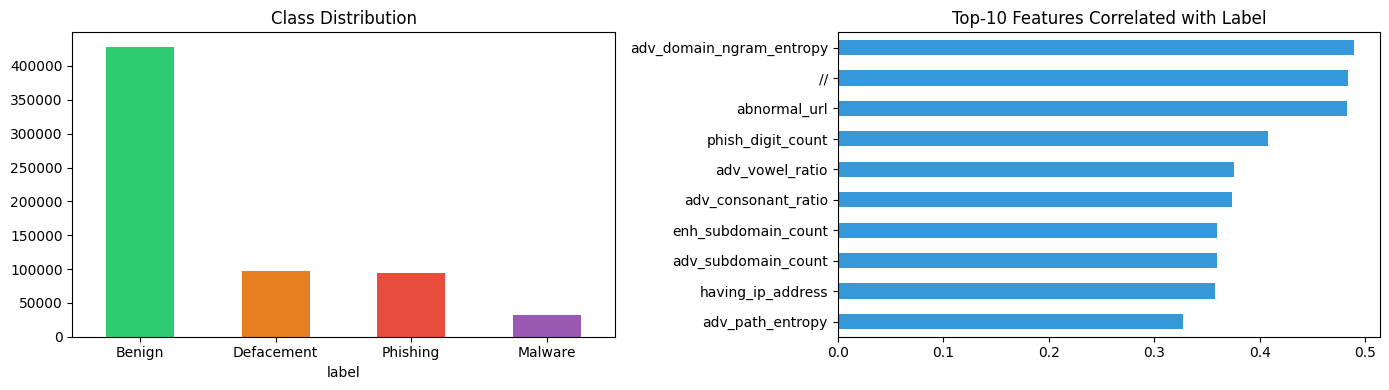

In [15]:
## Exploratory Data Analysis (EDA) for df1
fig, axes_1 = plt.subplots(1, 2, figsize=(14, 4))
labels_1 = ['Benign','Defacement','Phishing','Malware']

df1['label'].value_counts().sort_index().plot.bar(ax=axes_1[0], color=['#2ecc71','#e67e22','#e74c3c','#9b59b6'])
axes_1[0].set_xticklabels(labels_1, rotation=0);
axes_1[0].set_title('Class Distribution')

df1.corr()['label'].drop('label').abs().sort_values(ascending=False).head(10).plot.barh(ax=axes_1[1], color='#3498db')
axes_1[1].set_title('Top-10 Features Correlated with Label'); axes_1[1].invert_yaxis()
plt.tight_layout();
plt.show()

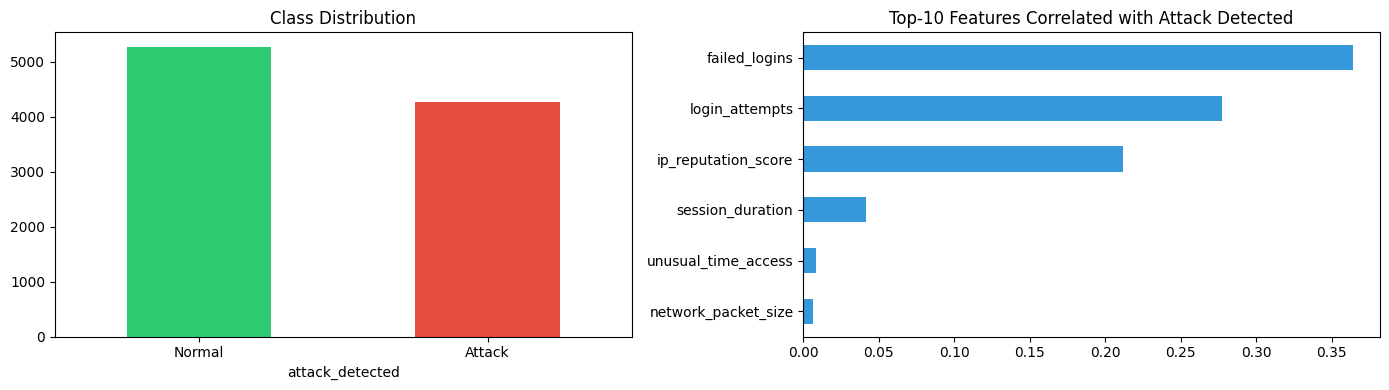

In [16]:
## Exploratory Data Analysis (EDA) for df2
fig, axes_2 = plt.subplots(1, 2, figsize=(14, 4))
labels_2 = ['Normal', 'Attack']

df2['attack_detected'].value_counts().sort_index().plot.bar(ax=axes_2[0], color=['#2ecc71', '#e74c3c'])
axes_2[0].set_xticklabels(labels_2, rotation=0);
axes_2[0].set_title('Class Distribution')

# Calculate correlation on numeric columns only to prevent errors
df2.select_dtypes(include=[np.number]).corr()['attack_detected'].drop('attack_detected').abs().sort_values(ascending=False).head(10).plot.barh(ax=axes_2[1], color='#3498db')
axes_2[1].set_title('Top-10 Features Correlated with Attack Detected'); axes_2[1].invert_yaxis()
plt.tight_layout();
plt.show()

In [17]:
## Model Training & Baseline Results for df1

models_1 = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=42)
}
results_1, predictions_1 = {}, {}

for name, m in models_1.items():
    m.fit(X_train_1, y_train_1)
    yp_1 = m.predict(X_test_1)
    predictions_1[name] = yp_1
    results_1[name] = {
        'Accuracy':  accuracy_score(y_test_1, yp_1),
        'Precision': precision_score(y_test_1, yp_1, average='weighted'),
        'Recall':    recall_score(y_test_1, yp_1, average='weighted'),
        'F1-Score':  f1_score(y_test_1, yp_1, average='weighted')
    }
    print(f"{name}: Acc={results_1[name]['Accuracy']:.4f}  Precision = {results_1[name]['Precision']:.4f} Recall = {results_1[name]['Recall']:.4f} F1={results_1[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.9568  Precision = 0.9566 Recall = 0.9568 F1=0.9567
KNN (k=5): Acc=0.9631  Precision = 0.9625 Recall = 0.9631 F1=0.9624
Logistic Reg: Acc=0.9010  Precision = 0.8979 Recall = 0.9010 F1=0.8933


In [18]:
## Model Training & Baseline Results for df2

models_2 = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=42)
}
results_2, predictions_2 = {}, {}

for name, m in models_2.items():
    m.fit(X_train_2, y_train_2)
    yp_2 = m.predict(X_test_2)
    predictions_2[name] = yp_2
    results_2[name] = {
        'Accuracy':  accuracy_score(y_test_2, yp_2),
        'Precision': precision_score(y_test_2, yp_2, average='binary'),
        'Recall':    recall_score(y_test_2, yp_2, average='binary'),
        'F1-Score':  f1_score(y_test_2, yp_2, average='binary')
    }
    print(f"{name}: Acc={results_2[name]['Accuracy']:.4f}  Precision = {results_2[name]['Precision']:.4f} Recall = {results_2[name]['Recall']:.4f} F1={results_2[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.8166  Precision = 0.7942 Recall = 0.7960 F1=0.7951
KNN (k=5): Acc=0.7914  Precision = 0.8605 Recall = 0.6366 F1=0.7318
Logistic Reg: Acc=0.7285  Precision = 0.7178 Recall = 0.6471 F1=0.6806


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8494     0.8211  0.8494    0.8169
5            0.8970     0.8980  0.8970    0.8876
10           0.9330     0.9333  0.9330    0.9296
15           0.9532     0.9528  0.9532    0.9516
20           0.9607     0.9601  0.9607    0.9596
None         0.9569     0.9566  0.9569    0.9568


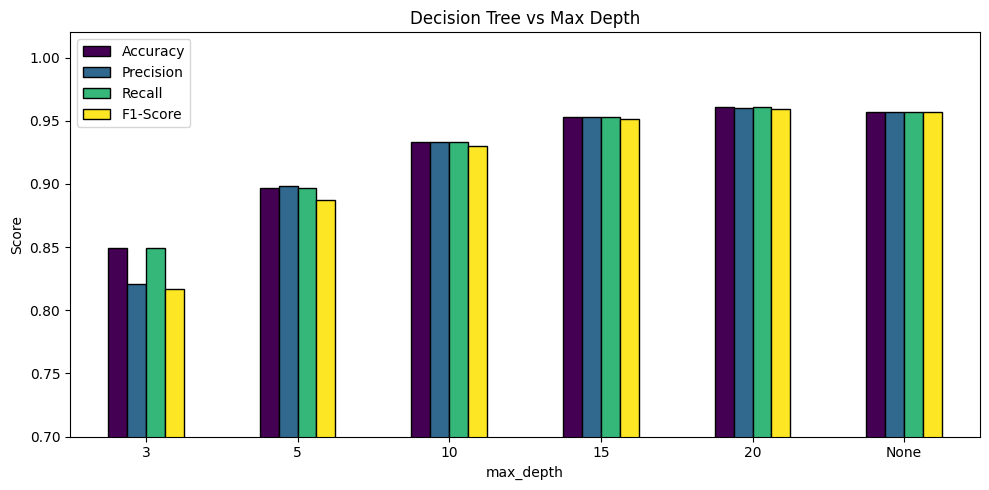

In [19]:
## Decision Tree — Depth Tuning for df1
dt_results_1 = []
for d in [3, 5, 10, 15, 20, None]:
    dt_1 = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train_1, y_train_1)
    yp_1 = dt_1.predict(X_test_1)
    dt_results_1.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test_1, yp_1), 'Precision': precision_score(y_test_1, yp_1, average='weighted'),
        'Recall': recall_score(y_test_1, yp_1, average='weighted'), 'F1-Score': f1_score(y_test_1, yp_1, average='weighted')})

dt_df_1 = pd.DataFrame(dt_results_1).set_index('max_depth')
print(dt_df_1.round(4))
dt_df_1.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8643     1.0000  0.6964    0.8210
5            0.8842     1.0000  0.7409    0.8512
10           0.8805     0.9815  0.7468    0.8482
15           0.8700     0.9403  0.7573    0.8390
20           0.8438     0.8599  0.7773    0.8165
None         0.8124     0.7902  0.7902    0.7902


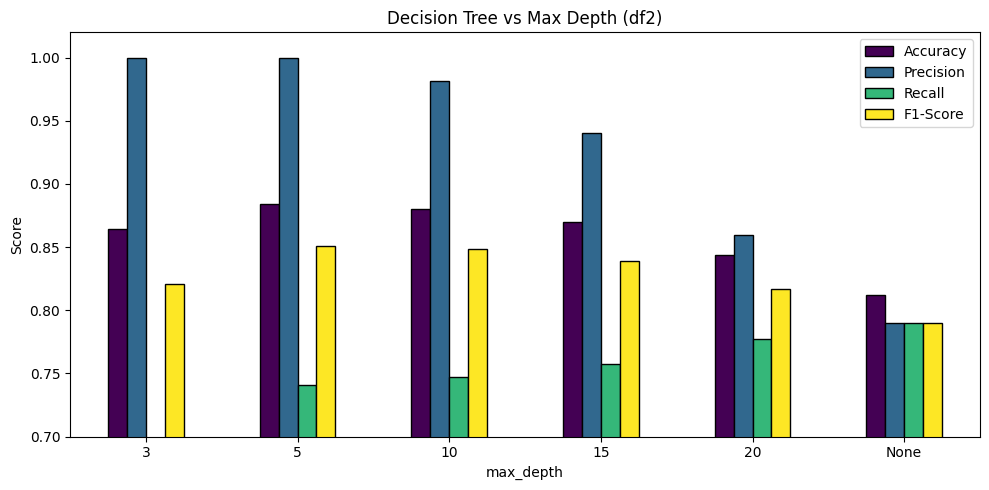

In [20]:
## Decision Tree — Depth Tuning for df2
dt_results_2 = []
for d in [3, 5, 10, 15, 20, None]:
    dt_2 = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train_2, y_train_2)
    yp_2 = dt_2.predict(X_test_2)
    dt_results_2.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test_2, yp_2), 'Precision': precision_score(y_test_2, yp_2, average='binary'),
        'Recall': recall_score(y_test_2, yp_2, average='binary'), 'F1-Score': f1_score(y_test_2, yp_2, average='binary')})

dt_df_2 = pd.DataFrame(dt_results_2).set_index('max_depth')
print(dt_df_2.round(4))
dt_df_2.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth (df2)'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


In [25]:
## Classification Reports
target_names_1 = ['Benign', 'Defacement', 'Phishing', 'Malware']
for name, yp_1 in predictions_1.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test_1, yp_1, target_names=target_names_1, digits=4))


Decision Tree
              precision    recall  f1-score   support

      Benign     0.9735    0.9763    0.9749     85657
  Defacement     0.9771    0.9783    0.9777     19291
    Phishing     0.8622    0.8504    0.8563     18787
     Malware     0.9470    0.9450    0.9460      6504

    accuracy                         0.9568    130239
   macro avg     0.9399    0.9375    0.9387    130239
weighted avg     0.9566    0.9568    0.9567    130239


KNN (k=5)
              precision    recall  f1-score   support

      Benign     0.9699    0.9887    0.9792     85657
  Defacement     0.9653    0.9876    0.9763     19291
    Phishing     0.9248    0.8325    0.8762     18787
     Malware     0.9648    0.9311    0.9477      6504

    accuracy                         0.9631    130239
   macro avg     0.9562    0.9350    0.9449    130239
weighted avg     0.9625    0.9631    0.9624    130239


Logistic Reg
              precision    recall  f1-score   support

      Benign     0.9134    0.9797  

In [26]:
## Classification Reports for df2
target_names_2 = ['Normal', 'Attack']
for name, yp_2 in predictions_2.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test_2, yp_2, target_names=target_names_2, digits=4))


Decision Tree
              precision    recall  f1-score   support

      Normal     0.8348    0.8332    0.8340      1055
      Attack     0.7942    0.7960    0.7951       853

    accuracy                         0.8166      1908
   macro avg     0.8145    0.8146    0.8145      1908
weighted avg     0.8166    0.8166    0.8166      1908


KNN (k=5)
              precision    recall  f1-score   support

      Normal     0.7572    0.9166    0.8293      1055
      Attack     0.8605    0.6366    0.7318       853

    accuracy                         0.7914      1908
   macro avg     0.8089    0.7766    0.7806      1908
weighted avg     0.8034    0.7914    0.7857      1908


Logistic Reg
              precision    recall  f1-score   support

      Normal     0.7357    0.7943    0.7639      1055
      Attack     0.7178    0.6471    0.6806       853

    accuracy                         0.7285      1908
   macro avg     0.7268    0.7207    0.7223      1908
weighted avg     0.7277    0.7285 

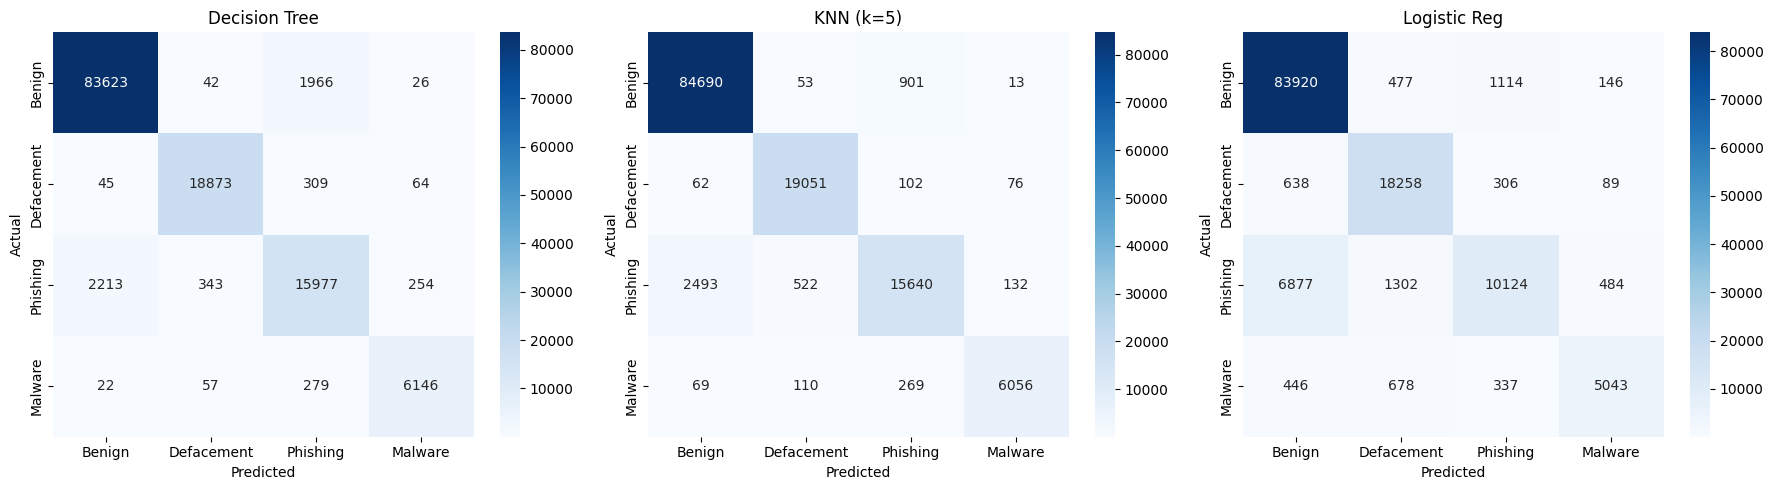

In [27]:
## Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp_1) in zip(axes, predictions_1.items()):
    sns.heatmap(confusion_matrix(y_test_1, yp_1), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names_1, yticklabels=target_names_1)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

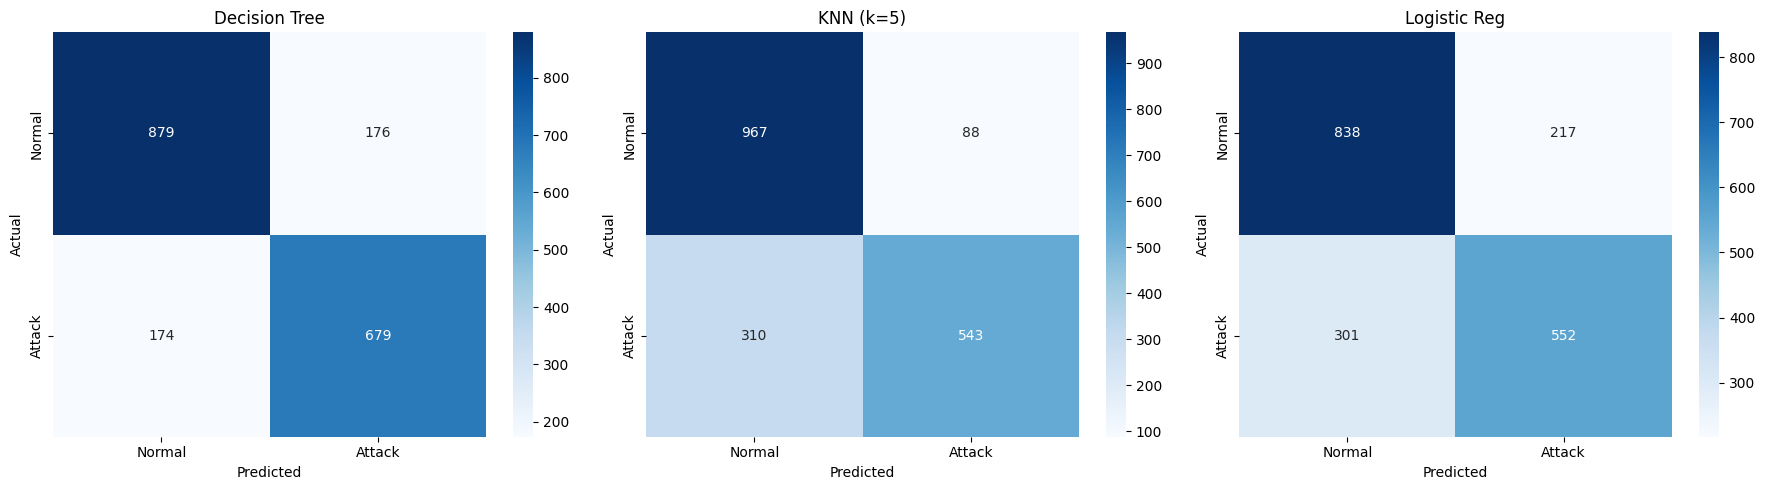

In [28]:
## Confusion Matrices for df2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp_2) in zip(axes, predictions_2.items()):
    sns.heatmap(confusion_matrix(y_test_2, yp_2), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names_2, yticklabels=target_names_2)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

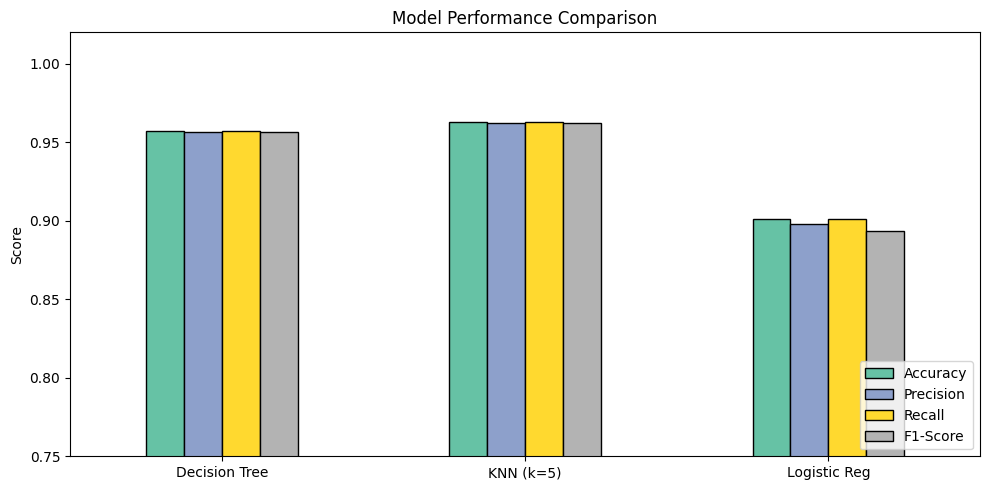


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.9568     0.9566  0.9568    0.9567
KNN (k=5)        0.9631     0.9625  0.9631    0.9624
Logistic Reg     0.9010     0.8979  0.9010    0.8933


In [30]:
##  Model Comparison
res_df_1 = pd.DataFrame(results_1).T
res_df_1.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df_1.round(4))

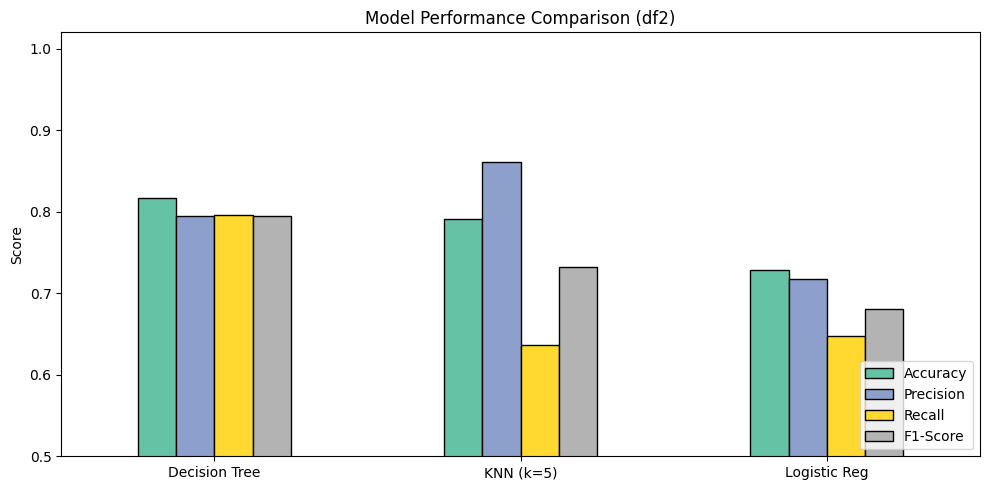


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.8166     0.7942  0.7960    0.7951
KNN (k=5)        0.7914     0.8605  0.6366    0.7318
Logistic Reg     0.7285     0.7178  0.6471    0.6806


In [32]:
##  Model Comparison for df2
res_df_2 = pd.DataFrame(results_2).T
res_df_2.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison (df2)'); plt.ylabel('Score'); plt.ylim(0.5, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df_2.round(4))